## E-Commerce Customer Analytics Project
**Dataset**: UCI Online Retail Dataset

**Goal:** Segment customers, predict segments for new customers, and forecast Customer Lifetime Value (CLV)

## Feature description

**InvoiceNo**: Invoice number. Nominal, a 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'c', it indicates a cancellation. 

**StockCode**: Product (item) code. Nominal, a 5-digit integral number uniquely assigned to each distinct product.
Description: Product (item) name. Nominal.

**Quantity**: The quantities of each product (item) per transaction. Numeric.

**InvoiceDate**: Invoice Date and time. Numeric, the day and time when each transaction was generated.

**UnitPrice**: Unit price. Numeric, Product price per unit in sterling.

**CustomerID**: Customer number. Nominal, a 5-digit integral number uniquely assigned to each customer.
Country: Country name. Nominal, the name of the country where each customer resides. 



### Importing necessary basic libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("online_retail.csv")
print(f'Shape: {df.shape}')
df.head()

Shape: (5000, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,550000,22752,SET 7 BABUSHKA NESTING BOXES,3,2011-05-19 00:04:01.968393,7.72,12860,United Kingdom
1,550001,22633,HAND WARMER UNION JACK,2,2011-06-03 23:17:22.048409,1.90,15444,Australia
2,550002,22632,HAND WARMER RED POLKA DOT,1,2011-11-12 15:51:44.540908,1.93,16493,France
3,550003,71053,WHITE METAL LANTERN,10,2011-04-01 23:53:22.480496,3.22,13154,United Kingdom
4,550004,22632,HAND WARMER RED POLKA DOT,1,2011-04-11 02:21:43.460692,1.83,14693,United Kingdom


### Exploratory data analysis

In [4]:
print('Dataset Info')
print(df.info())
print('\n\nMissing Values')
print(df.isnull().sum())
print('\n\nBasic Stats')
df.describe()

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    5000 non-null   int64  
 1   StockCode    5000 non-null   object 
 2   Description  5000 non-null   object 
 3   Quantity     5000 non-null   int64  
 4   InvoiceDate  5000 non-null   object 
 5   UnitPrice    5000 non-null   float64
 6   CustomerID   5000 non-null   int64  
 7   Country      5000 non-null   object 
dtypes: float64(1), int64(3), object(4)
memory usage: 312.6+ KB
None


Missing Values
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


Basic Stats


,InvoiceNo,Quantity,UnitPrice,CustomerID
count,5000.000000,5000.000000,5000.000000,5000.00000
mean,552499.500000,3.739400,3.176058,15102.99580
std,1443.520003,3.725515,1.814274,1755.35359
min,550000.000000,-12.000000,0.520000,12004.00000
25%,551249.750000,2.000000,1.900000,13597.00000
50%,552499.500000,3.000000,2.870000,15104.00000
75%,553749.250000,5.000000,3.510000,16723.00000
max,554999.000000,12.000000,8.030000,17991.00000


## Data Cleaning

### Let's convert the InvoiceDate to Datetime type

In [5]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='mixed')

In [6]:
df.dtypes

InvoiceNo               int64
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
dtype: object

### Remove cancellations (InvoiceNo starts with 'C')


In [11]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

### Remove rows with missing CustomerID

In [ ]:
df = df.dropna(subset=['CustomerID'])
# Here there is no missing values of CustomerID but in general case there might be.


### Remove negative quantities and prices


In [8]:
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]


### Create a Revenue column


In [10]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

### Converting the CustomerID to int datatype

In [12]:
df['CustomerID'] = df['CustomerID'].astype(int)

print('Shape after cleaning:', df.shape)
print('Unique customers:', df['CustomerID'].nunique())

Shape after cleaning: (4747, 9)
Unique customers: 473


### Dataset summary after cleanup

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4747 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    4747 non-null   int64         
 1   StockCode    4747 non-null   object        
 2   Description  4747 non-null   object        
 3   Quantity     4747 non-null   int64         
 4   InvoiceDate  4747 non-null   datetime64[ns]
 5   UnitPrice    4747 non-null   float64       
 6   CustomerID   4747 non-null   int64         
 7   Country      4747 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(3)
memory usage: 333.8+ KB


### Now we see how much revenue comes from each country
Looking at the first 15 countries

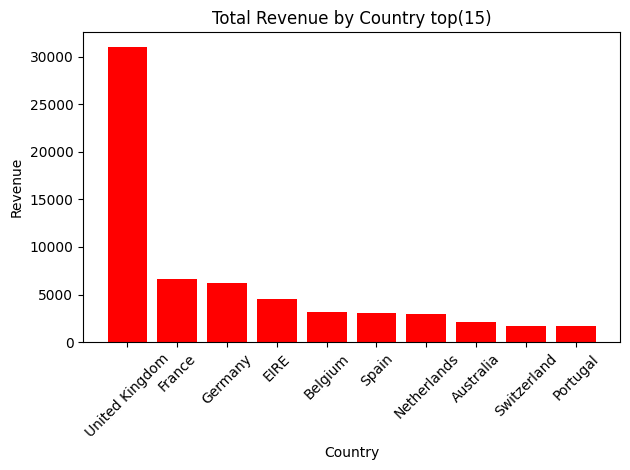

In [24]:
revenue_by_country = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(15)

plt.bar(revenue_by_country.index,revenue_by_country.values,color = 'red')
plt.title("Total Revenue by Country top(15)")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

### How many orders per month?

In [13]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

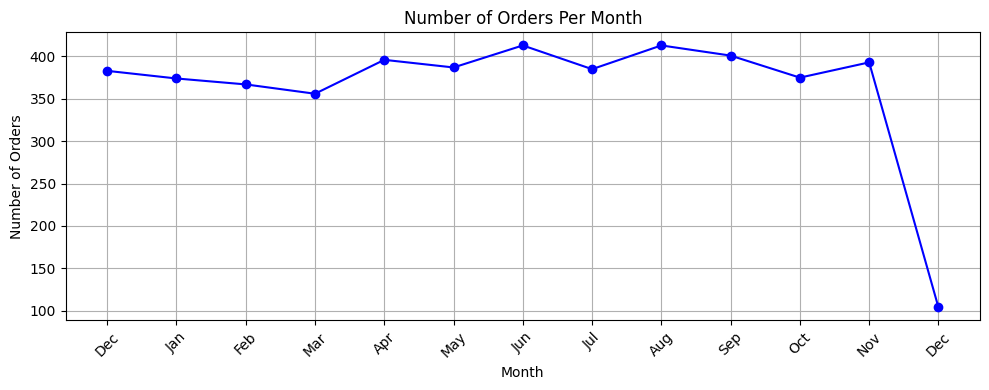

In [62]:
orders_per_month = df.groupby('Month')['InvoiceNo'].nunique()
plt.figure(figsize=(10, 4))
plt.plot(orders_per_month.index.astype(str), orders_per_month.values, marker='o', color='blue')
plt.title('Number of Orders Per Month')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(
    ticks=range(len(orders_per_month)),
    labels=[p.to_timestamp().strftime('%b') for p in orders_per_month.index],
    rotation=45
)
plt.grid(True)
plt.tight_layout()
plt.show()

### RFM Feature Engineering

We summarise each customer into 3 numbers:

- **Recency** — How many days ago did they last buy? (lower = better)
- **Frequency** — How many times did they buy? (higher = better)
- **Monetary** — How much total did they spend? (higher = better)

This converts thousands of transactions into one row per customer.

In [18]:
# Reference date: 1 day after the last invoice
ref_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
# So that if a customer buys on the last date he/she gets recency value 1 not 0
rfm = df.groupby('CustomerID').agg(
    Recency = ('InvoiceDate',lambda x:(ref_date - x.max()).days),
    Frequency = ('InvoiceNo','nunique'),
    Monetary = ('Revenue','sum')
).reset_index().sort_values('CustomerID')
print('RFM table shape:', rfm.shape)
print('\nFirst 5 rows:')
rfm.head()


RFM table shape: (473, 4)

First 5 rows:


,CustomerID,Recency,Frequency,Monetary
0,12004,1,8,127.23
1,12016,36,12,245.60
2,12034,24,10,105.50
3,12064,20,6,73.30
4,12098,113,9,99.07


### Plotting Distribution of rfm values

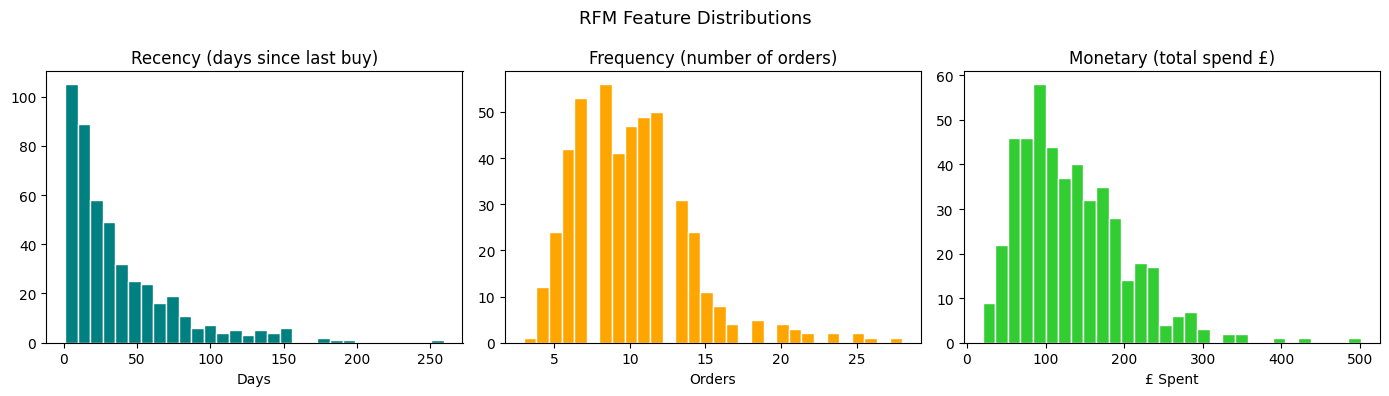

All 3 are skewed — we will log transform them before clustering.


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(rfm['Recency'], bins=30, color='teal', edgecolor='white')
axes[0].set_title('Recency (days since last buy)')
axes[0].set_xlabel('Days')

axes[1].hist(rfm['Frequency'], bins=30, color='orange', edgecolor='white')
axes[1].set_title('Frequency (number of orders)')
axes[1].set_xlabel('Orders')

axes[2].hist(rfm['Monetary'], bins=30, color='limegreen', edgecolor='white')
axes[2].set_title('Monetary (total spend £)')
axes[2].set_xlabel('£ Spent')

plt.suptitle('RFM Feature Distributions', fontsize=13)
plt.tight_layout()
plt.show()

print('All 3 are skewed — we will log transform them before clustering.')

### Log transform to reduce skewness

In [21]:
rfm['R_log'] = np.log1p(rfm['Recency'])
rfm['F_log'] = np.log1p(rfm['Frequency'])
rfm['M_log'] = np.log1p(rfm['Monetary'])

### We scale the data as they belong to different scales using standard scaler

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['R_log','F_log','M_log']])
rfm_scaled

array([[-2.35983562, -0.44384158,  0.15822242],
       [ 0.43038373,  0.65865248,  1.39548803],
       [ 0.0554799 ,  0.15779927, -0.19308721],
       ...,
       [ 0.29154841,  0.41867244,  0.59326446],
       [-1.69698961,  0.65865248,  0.56396334],
       [-1.48360086,  0.8808393 ,  0.42746521]], shape=(473, 3))

### Now we convert the transformed(log) scaled values to a dataframe

In [23]:
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['R_scaled', 'F_scaled', 'M_scaled'], index=rfm['CustomerID'])

print(rfm_scaled_df.head())

            R_scaled  F_scaled  M_scaled
CustomerID                              
12004      -2.359836 -0.443842  0.158222
12016       0.430384  0.658652  1.395488
12034       0.055480  0.157799 -0.193087
12064      -0.111252 -1.197320 -0.874276
12098       1.506472 -0.127955 -0.310912


## Choosing the optimal number of clusters

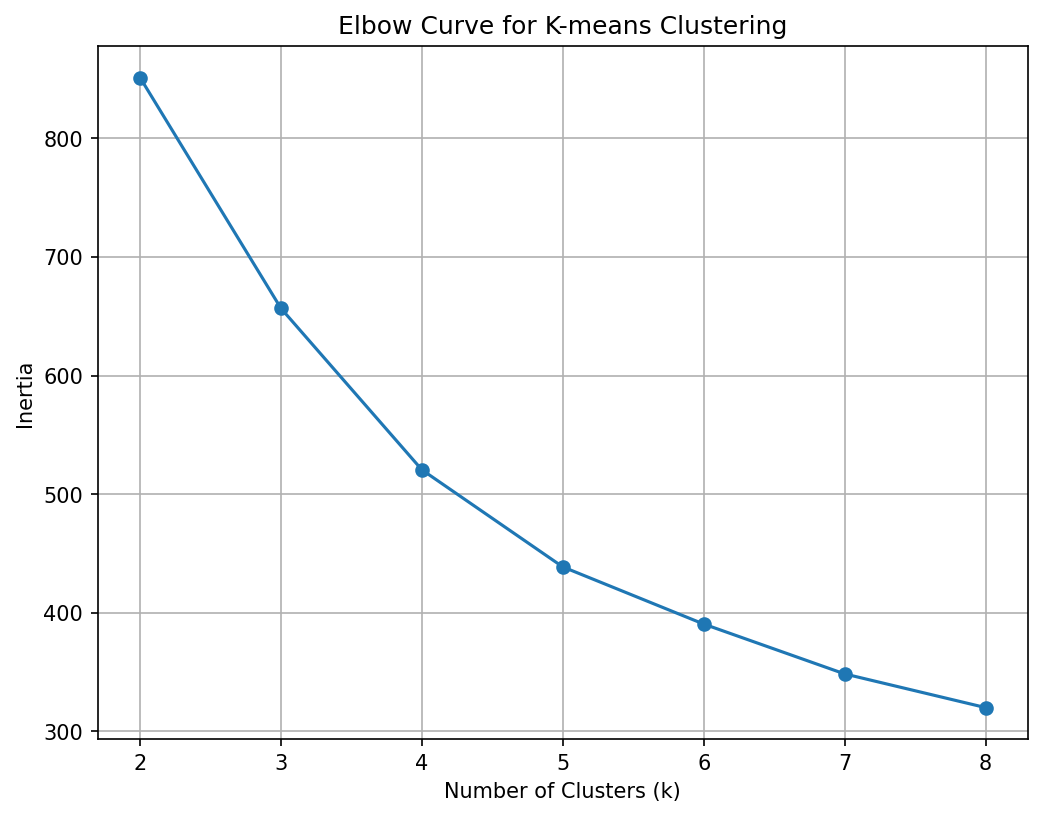

In [25]:
from sklearn.cluster import KMeans
# Calculating inertia (sum of squared distances) for different values of k
inertia = []
for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, n_init= 10, random_state=42)
    kmeans.fit(rfm_scaled_df)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 6),dpi=150)
plt.plot(range(2, 9), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Curve for K-means Clustering')
plt.grid(True)
plt.show()

#### The distribution is properly decreasing no elbow being seen we use silhoutte score, we can say the clusters starts to flatten out after k=4,5

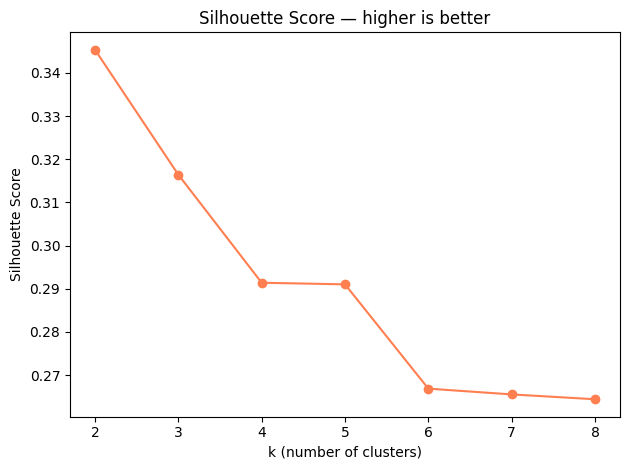

In [26]:
from sklearn.metrics import silhouette_score
silhouettes = []

for k in range(2,9):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(rfm_scaled)
    silhouettes.append(silhouette_score(rfm_scaled, labels))

# Plotting silhouette scores
plt.plot(range(2,9), silhouettes, marker='o', color='coral')
plt.title('Silhouette Score — higher is better')
plt.xlabel('k (number of clusters)')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

## Choosing Optimal k = 4

**Elbow Curve:** The inertia drops steeply from k=2 to k=4, then flattens significantly after k=4 — indicating that adding more clusters beyond 4 yields diminishing returns in compactness.

**Silhouette Score:** Although k=2 scores highest (~0.345), it is too coarse for meaningful segmentation. The score plateaus at k=4 and k=5 (~0.291) before dropping sharply at k≥6, making k=4 the last point of good cluster separation.
### Conclusion
Together, k=4 gives a good balance between compactness and separation, 
and the 4 groups map well to real customer types (Champions, Loyal, At Risk, Lost).

In [30]:
# Fit K-Means with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

score = silhouette_score(rfm_scaled, rfm['Cluster'])
print(f'Silhouette Score with k=4: {score:.4f}')
print('\nCustomers in each cluster:')
print(rfm['Cluster'].value_counts().sort_index())

Silhouette Score with k=4: 0.2914

Customers in each cluster:
Cluster
0    100
1    125
2    156
3     92
Name: count, dtype: int64


### Average rfm values in each cluster

In [71]:
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
print(cluster_summary)

         Recency  Frequency  Monetary
Cluster                              
0            6.5       10.0     119.3
1           50.4        6.3      65.9
2           56.8        9.9     139.5
3           19.0       15.4     230.5


In [ ]:
# Assigning human-readable names based on spend
# Champions = highest spend, Lost = lowest
spend_rank = cluster_summary['Monetary'].rank(ascending=False).astype(int)
name_map = {}
for cluster_id, rank in spend_rank.items():
    if rank == 1: name_map[cluster_id] = 'Champions'
    elif rank == 2: name_map[cluster_id] = 'Loyal'
    elif rank == 3: name_map[cluster_id] = 'At Risk'
    else: name_map[cluster_id] = 'Lost'

rfm['Segment'] = rfm['Cluster'].map(name_map)
print('\nSegment counts:')
print(rfm['Segment'].value_counts())


Segment counts:
Segment
Loyal        156
Lost         125
At Risk      100
Champions     92
Name: count, dtype: int64


### Heatmap of Cluster Summary

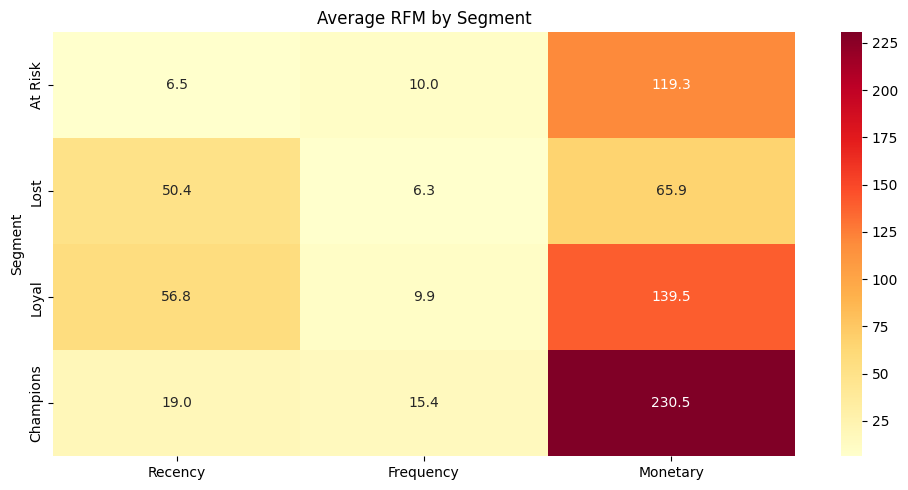

In [72]:
plt.figure(figsize=(10, 5))
sns.heatmap(cluster_summary.set_index(rfm.groupby('Cluster')['Segment'].first()),
            annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Average RFM by Segment')
plt.tight_layout()
plt.show()

### Visualizing the clusters in 2d using Principal Component Analysis

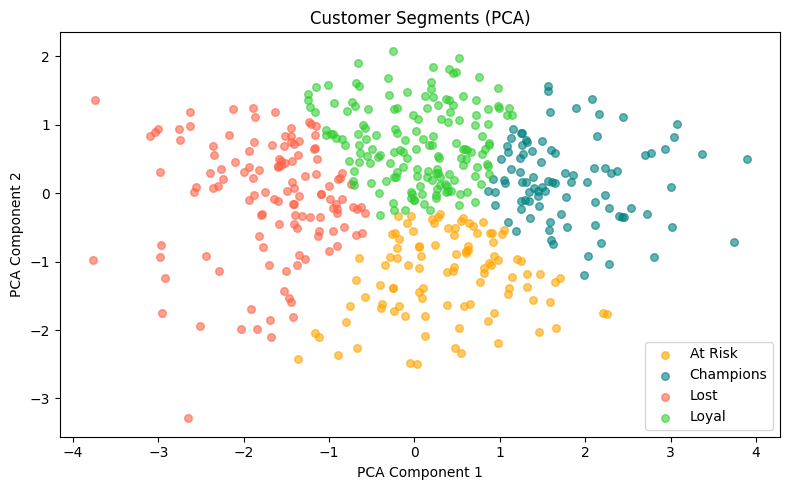

In [34]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 2D
pca = PCA(n_components=2)
components = pca.fit_transform(rfm_scaled)

rfm['PCA1'] = components[:, 0]
rfm['PCA2'] = components[:, 1]

# Plot
colors = {'Champions': 'teal', 'Loyal': 'limegreen', 'At Risk': 'orange', 'Lost': 'tomato'}

plt.figure(figsize=(8, 5))
for segment, group in rfm.groupby('Segment'):
    plt.scatter(group['PCA1'], group['PCA2'], label=segment, color=colors[segment], alpha=0.6, s=30)

plt.title('Customer Segments (PCA)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.tight_layout()
plt.show()

### Visualizing the clusters in 3d using plotly.express and PCA

In [48]:
import plotly.express as px

# Reduce to 3D
pca3 = PCA(n_components=3)
components3 = pca3.fit_transform(rfm_scaled)

rfm['PCA1'] = components3[:, 0]
rfm['PCA2'] = components3[:, 1]
rfm['PCA3'] = components3[:, 2]

# Interactive 3D scatter
fig = px.scatter_3d(
    rfm, x='PCA1', y='PCA2', z='PCA3',
    color='Segment',
    color_discrete_map={'Champions': 'teal', 'Loyal': 'limegreen', 'At Risk': 'orange', 'Lost': 'tomato'},
    title='Customer Segments — Interactive 3D PCA',
    opacity=0.6,
    size_max=5
)
fig.update_layout(
    legend_title_text='Segment',
    scene_camera=dict(
        eye=dict(x=1.0, y=1.0, z=0.8)  # lower z = more zoomed in
    )
)
fig.update_traces(marker=dict(size=3))
fig.show()

### We plot the average spend per segment

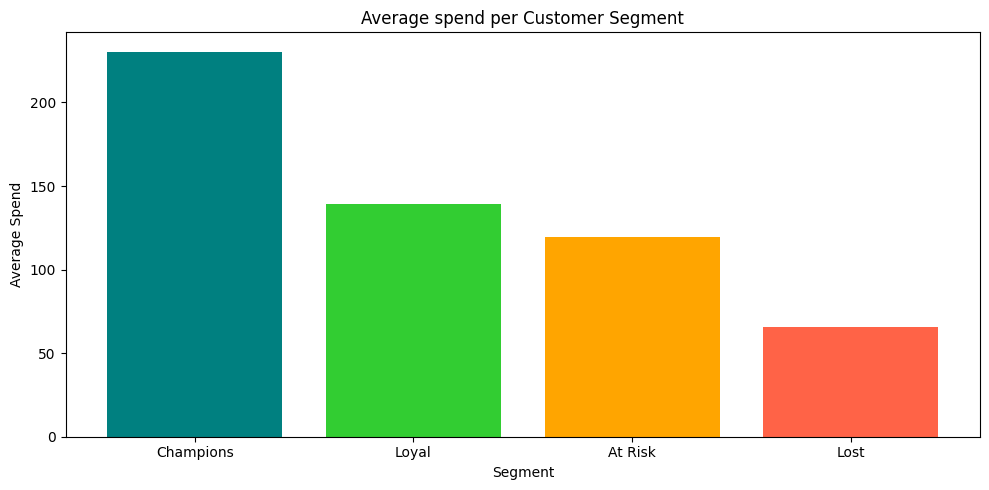

In [64]:
avg_spend = rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending = False)

plt.figure(figsize=(10,5))
plt.bar(avg_spend.index,avg_spend.values,color = ['teal','limegreen','orange','tomato'])
plt.title('Average spend per Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Average Spend')
plt.tight_layout()
plt.show()

### Now we do a scatter plot the Recency vs Monetary with color as  segments

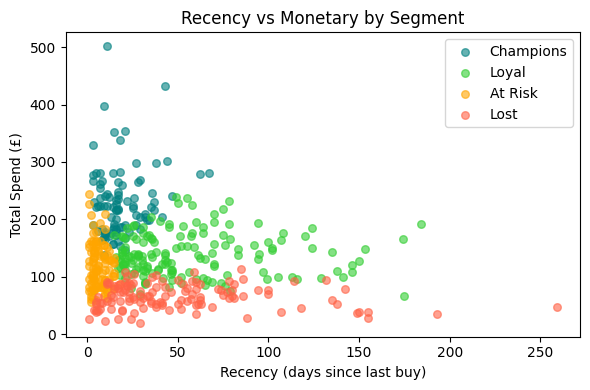

In [63]:
colors = {
    'Champions':'teal',
    'Loyal':'limegreen',
    'At Risk':'orange',
    'Lost':'tomato'
}

plt.figure(figsize=(6, 4))
for seg, color in colors.items():
    data = rfm[rfm['Segment'] == seg]
    plt.scatter(data['Recency'], data['Monetary'], color=color, label=seg, alpha=0.6, s=30)

plt.title('Recency vs Monetary by Segment')
plt.xlabel('Recency (days since last buy)')
plt.ylabel('Total Spend (£)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### Classification — Predict Customer Segment

**Problem:** Given a new customer's RFM values, predict which segment they belong to.

**Why?** We can't run K-Means on a single new customer. Instead, train a classifier on the existing cluster labels.

**Model:** We compare the models on the basis of different F1 score as the classes are mostly imbalanced

In [49]:
from sklearn.model_selection import train_test_split
# Features: Recency, Frequency, Monetary
# Target: Segment (Champions / Loyal / At Risk / Lost)

X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Segment']

# Split into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training samples:', len(X_train))
print('Testing samples: ', len(X_test))

Training samples: 378
Testing samples:  95


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

# Defining all classifiers
classifiers = {
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=5000, random_state=42),
    'KNN'                : KNeighborsClassifier(n_neighbors=5)
}

# Training each one and record F1 score
results = {}
for name, model in classifiers.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    f1 = f1_score(y_test, preds, average='weighted')
    results[name] = f1
    print(f'{name:25s}  F1 Score: {f1:.4f}')

# Picking the best one
best_name = max(results, key=results.get)
print(f'\nBest classifier: {best_name} with F1 = {results[best_name]:.4f}')

Random Forest              F1 Score: 0.9372
Decision Tree              F1 Score: 0.9472
Logistic Regression        F1 Score: 0.9790
KNN                        F1 Score: 0.8092

Best classifier: Logistic Regression with F1 = 0.9790


In [59]:
from sklearn.metrics import classification_report
clf = classifiers[best_name]
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

print('Classification Report:')
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

     At Risk       1.00      1.00      1.00        21
   Champions       0.94      1.00      0.97        16
        Lost       0.94      1.00      0.97        16
       Loyal       1.00      0.95      0.98        42

    accuracy                           0.98        95
   macro avg       0.97      0.99      0.98        95
weighted avg       0.98      0.98      0.98        95



<Figure size 700x500 with 0 Axes>

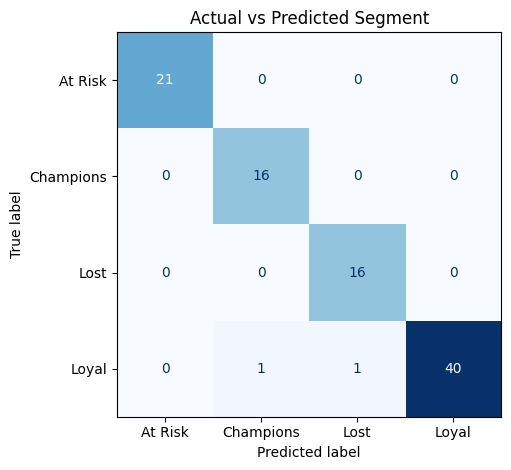

Numbers on the diagonal = correct predictions
Numbers off the diagonal = wrong predictions


In [60]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=clf.classes_)

plt.figure(figsize=(7, 5))
disp.plot(colorbar=False, cmap='Blues')
plt.title('Actual vs Predicted Segment')
plt.tight_layout()
plt.show()

print('Numbers on the diagonal = correct predictions')
print('Numbers off the diagonal = wrong predictions')

### Testing the classifier with a random test data

In [52]:
import random

# Picking a random sample from test set
random_idx = random.randint(0, len(X_test) - 1)
sample = X_test.iloc[random_idx]
actual_segment = y_test.iloc[random_idx]

best_model = classifiers[best_name]
# Predicting its class value
predicted_segment = best_model.predict(pd.DataFrame([sample]))[0]

# Display
print('Customer Features:')
print(f'  Recency   : {sample["Recency"]} days')
print(f'  Frequency : {sample["Frequency"]} orders')
print(f'  Monetary  : £{sample["Monetary"]:.2f}')
print()
print(f'Actual Segment    : {actual_segment}')
print(f'Predicted Segment : {predicted_segment}')
print()
if predicted_segment == actual_segment:
    print('CORRECTLY CLASSIFIED')
else:
    print('WRONGLY CLASSIFIED')

Customer Features:
  Recency   : 27.0 days
  Frequency : 13.0 orders
  Monetary  : £207.18

Actual Segment    : Champions
Predicted Segment : Champions

CORRECTLY CLASSIFIED


### Regression — Predict Customer Lifetime Value (CLV)

**Problem:** Predict how much total money a customer will spend (their Monetary value).

**Features used:** Recency, Frequency, and which Segment they belong to.

**Model:** Comparing different regressors and the use the best based on lowest RMSE


In [65]:
# Encode segment as a number (Random Forest needs numbers, not text)
segment_encoding = {'Champions': 3, 'Loyal': 2, 'At Risk': 1, 'Lost': 0}
rfm['Segment_Num'] = rfm['Segment'].map(segment_encoding)

# Features: Recency, Frequency, Segment number
# Target: Monetary (how much they spent)
# We use log(Monetary) because the values are very spread out
X_reg = rfm[['Recency', 'Frequency', 'Segment_Num']]
y_reg = np.log1p(rfm['Monetary'])  # log transform target
# Note: Segment is derived from Monetary, so this is more of a consistency check than true prediction
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

print('Training samples:', len(X_train_r))


Training samples: 378


In [54]:
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor ,GradientBoostingRegressor
from sklearn.metrics import r2_score,mean_squared_error

regressors = {
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42),
    'Decision Tree'     : DecisionTreeRegressor(random_state=42),
    'Ridge Regression'  : Ridge(),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100, random_state=42)
}
# Train each one and record scores
results_reg = {}
for name, model in regressors.items():
    model.fit(X_train_r, y_train_r)
    preds = model.predict(X_test_r)
    rmse = np.sqrt(mean_squared_error(y_test_r, preds))
    r2   = r2_score(y_test_r, preds)
    results_reg[name] = {'model': model, 'rmse': rmse, 'r2': r2}
    print(f'{name:20s}  RMSE: {rmse:.4f}  R²: {r2:.4f}')

# Pick best model based on lowest RMSE
best_reg_name = min(results_reg, key=lambda x: results_reg[x]['rmse'])
best_reg_model = results_reg[best_reg_name]['model']
print(f'\nBest Regressor: {best_reg_name}')

Random Forest         RMSE: 0.2627  R²: 0.6556
Decision Tree         RMSE: 0.3092  R²: 0.5229
Ridge Regression      RMSE: 0.2733  R²: 0.6273
Gradient Boosting     RMSE: 0.2582  R²: 0.6673

Best Regressor: Gradient Boosting


In [55]:
y_pred_r = best_reg_model.predict(X_test_r)

rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2   = r2_score(y_test_r, y_pred_r)

print(f'Final Regressor : {best_reg_name}')
print(f'RMSE            : {rmse:.4f}')
print(f'R²              : {r2:.4f}')

Final Regressor : Gradient Boosting
RMSE            : 0.2582
R²              : 0.6673


### Plotting Actual vs Predicted CLV

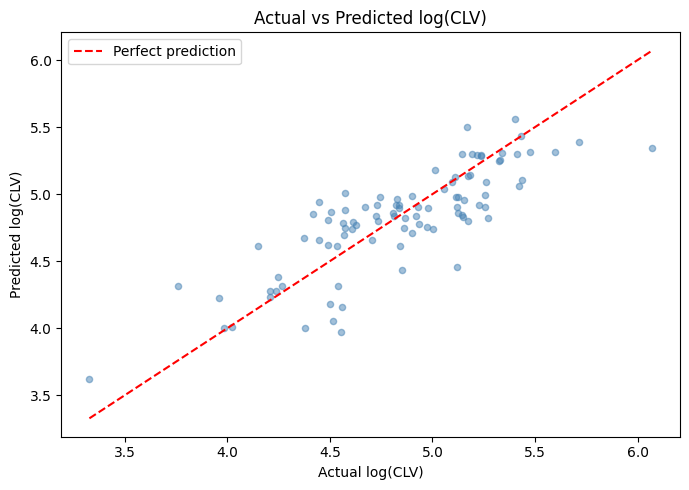

Points close to the red line = good predictions


In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test_r, y_pred_r, alpha=0.5, color='steelblue', s=20)
plt.plot([y_test_r.min(), y_test_r.max()],
         [y_test_r.min(), y_test_r.max()], 'r--', label='Perfect prediction')
plt.title('Actual vs Predicted log(CLV)')
plt.xlabel('Actual log(CLV)')
plt.ylabel('Predicted log(CLV)')
plt.legend()
plt.tight_layout()
plt.show()

print('Points close to the red line = good predictions')

### Feature importance for regression


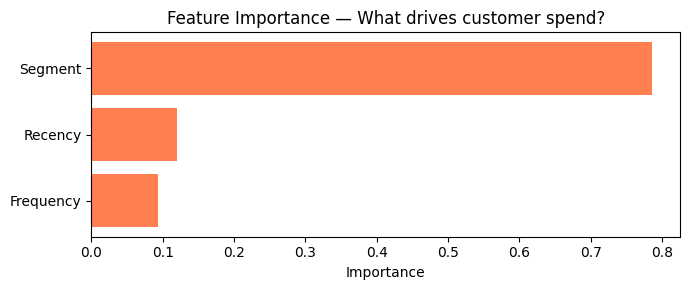

In [61]:
reg_importances = pd.Series(best_reg_model.feature_importances_,
                            index=['Recency', 'Frequency', 'Segment']).sort_values()

plt.figure(figsize=(7, 3))
plt.barh(reg_importances.index, reg_importances.values, color='coral')
plt.title('Feature Importance — What drives customer spend?')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Conclusion
Started with raw transaction data, cleaned it, built RFM features, and used 
K-Means to group customers into 4 segments. Then trained classifiers to predict 
segments for new customers (best F1: ~0.98) and regressors to estimate spend 
(best R²: ~0.67). 

**Key takeaway** — Recency matters most.

**Recommended Actions:**
- Champions → Can give loyalty rewards to keep them happy, early access to new products
- At Risk → personalised win-back email or ad campaign so that they restart their shopping journey again
- Lost → Send a one-time "We miss you" discount coupon (10-15% off). If they still don't respond after 2-3 months, deprioritise marketing spend on them — the cost of chasing them outweighs the return.
